In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

c = 'coral'
c1 = 'yellowgreen'
base_c = 'aqua'

plt.rcParams['text.usetex'] = False
sns.set(style="ticks")
plt.rc('font', family='serif')
#plt.rc('font', serif='Times New Roman')

largefont = 32
bigfont   = 20
medfont   = 20
smallfont = 17

plt.rcParams['xtick.labelsize']=medfont
plt.rcParams['ytick.labelsize']=medfont

#sns.set_style('ticks', {'font.family':'serif', 'font.serif':'Times New Roman', 'font.size': 16})
sns.set_palette("muted")

ticks_fontsize = 18
label_fontsize = 20
cbar_fontsize = 18

import matplotlib.font_manager

def generate_plots(x_label_list, y_label_list, data, vmin, vmax, title, ylabel, xlabel, save_path, cmap='Blues'):
    fig, ax = plt.subplots(figsize=(len(x_label_list) * 0.5, len(y_label_list) * 0.5))
    
    # Calculate extent based on data dimensions
    x_extent = [0.5, len(x_label_list) + 0.5]
    y_extent = [len(y_label_list) + 0.5, 0.5]
    
    # Use imshow with adjusted extent
    pos = ax.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect='equal',
        origin='upper',
        extent=[x_extent[0], x_extent[1], y_extent[1], y_extent[0]]
    )
    
    plt.title(title, y=1.01, fontsize=bigfont)
    plt.xlabel(xlabel, fontsize=medfont)
    plt.ylabel(ylabel, fontsize=medfont)
    
    # Set ticks to match the center of each cell
    plt.yticks(
        range(1, len(y_label_list) + 1),
        y_label_list,
        fontsize=ticks_fontsize
    )
    plt.xticks(
        range(1, len(x_label_list) + 1),
        [int(item) for item in x_label_list],
        fontsize=ticks_fontsize
    )
    
    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.15)
    cbar = plt.colorbar(pos, cax=cax)
    cbar.ax.tick_params(labelsize=cbar_fontsize)
    
    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight')



def min_normalize(matrix, axis=1, topk=1):
    #print(matrix.shape)
    matrix_norm = matrix.copy()
    min_v = np.nanmin(matrix, axis=axis, keepdims=True)
    max_v = np.nanmax(matrix, axis=axis, keepdims=True)

    range_v = max_v - min_v
    range_v[range_v == 0] = 1  # 避免除以零
    
    # 归一化
    matrix_norm = (matrix - min_v) / range_v
    
    return matrix_norm

In [2]:
# Configuration parameters
k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.001] 
sub_sampling_range = [256, 128, 64, 32, 16, 8, 4, 2, 1]  ##4096, 2048, 1024, 512, 

# Calculate actual data numbers based on subsample ratio
# Total data amount is 32768, subsample ratio determines how much is used
total_data = 32768
data_number_range = [str(total_data // subsample) for subsample in sub_sampling_range]

seed_range = [2021, 2022, 2023, 2024, 2025]
curve_types = ['linear', 'bezier']

# Base directory for mode connectivity results
base_mc_dir = './mode_connectivity_analysis'

print(f"Configuration loaded:")
print(f"  K ranges: {len(k_ranges)} settings")
print(f"  Subsample ranges: {len(sub_sampling_range)} settings")
print(f"  Actual data numbers: {data_number_range}")
print(f"  Seeds: {len(seed_range)} seeds")
print(f"  Curve types: {curve_types}")


Configuration loaded:
  K ranges: 8 settings
  Subsample ranges: 9 settings
  Actual data numbers: ['128', '256', '512', '1024', '2048', '4096', '8192', '16384', '32768']
  Seeds: 5 seeds
  Curve types: ['linear', 'bezier']


In [3]:
# Create k_range labels for visualization
k_range_list = []
for k_range in k_ranges:
    if k_range[0]>=10.0:
        k_range_list.append(f'{int(k_range[0])}-')
    else:
        k_range_list.append(f'{k_range[0]}-')

print(f"K-range labels: {k_range_list}")


K-range labels: ['1.0-', '2.5-', '5.0-', '10-', '20-', '30-', '50-', '100-']


In [4]:
def parse_mode_connectivity_file(file_path):
    """
    Parse mode connectivity result file and extract metrics.
    
    Expected format:
    mode_connectivity: -0.14786728
    loss_a: 0.37627347
    loss_b: 0.08053890
    avg_endpoint_loss: 0.22840619
    optimal_t: 0.00000000
    optimal_loss: 0.37627347
    min_difference: 0.14786728
    curve_type: linear
    optimize_control_point: False
    loss_barrier_height: 583.62194324
    loss_curve_min: 0.08053890
    loss_curve_max: 583.85034943
    parameter_distance: 312.13278198
    """
    results = {}
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                line = line.strip()
                if ':' in line and not line.startswith('=') and not line.startswith('-'):
                    key, value = line.split(':', 1)
                    key = key.strip()
                    value = value.strip()
                    
                    # Convert to appropriate types
                    if key in ['mode_connectivity', 'loss_a', 'loss_b', 'avg_endpoint_loss', 
                              'optimal_t', 'optimal_loss', 'min_difference', 'loss_barrier_height',
                              'loss_curve_min', 'loss_curve_max', 'parameter_distance']:
                        try:
                            results[key] = float(value)
                        except ValueError:
                            results[key] = value
                    elif key in ['optimize_control_point']:
                        results[key] = value.lower() == 'true'
                    elif key in ['Batches processed', 'Curve points evaluated']:
                        try:
                            results[key] = int(value)
                        except ValueError:
                            results[key] = value
                    else:
                        results[key] = value
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None
    
    return results

# Test the parser with the example file if it exists
test_file = "mode_connectivity_analysis/expts_eps75/poisson_scale_k2.5_5.0_val1024_1M/_vs__linear/bsz128_lr0.001_subsample2/seed2023_vs_2021/mode_connectivity_linear_results.txt"
if os.path.exists(test_file):
    test_result = parse_mode_connectivity_file(test_file)
    print("Test parsing result:")
    for key, value in test_result.items():
        print(f"  {key}: {value}")
else:
    print(f"Test file not found: {test_file}")


Test parsing result:
  Checkpoint A: results_sameiteration/expts_eps75/poisson_scale_k2.5_5.0_val1024_1M/train/bsz128_lr0.001_subsample2/seed2023/checkpoints/ckpt.tar
  Checkpoint B: results_sameiteration/expts_eps75/poisson_scale_k2.5_5.0_val1024_1M/train/bsz128_lr0.001_subsample2/seed2021/checkpoints/ckpt.tar
  Curve Type: linear
  Data type: training
  Batches processed: 8
  Curve points evaluated: 21
  mode_connectivity: -0.23370605
  loss_a: 0.61274836
  loss_b: 0.14533626
  avg_endpoint_loss: 0.37904231
  optimal_t: 0.0
  optimal_loss: 0.61274836
  min_difference: 0.23370605
  curve_type: linear
  optimize_control_point: False
  loss_barrier_height: 1003.67586644
  loss_curve_min: 0.14533626
  loss_curve_max: 1004.05490875
  parameter_distance: 312.13278198


In [5]:
def get_batch_size_for_subsample(subsamples):
    """Get the appropriate batch size for given subsample value."""
    if subsamples == 512:
        return 64
    elif subsamples == 1024:
        return 32
    elif subsamples == 2048:
        return 16
    elif subsamples == 4096:
        return 8
    else:
        return 128  # default batch size

def get_experiment_epochs(subsamples):
    """Get the experiment epochs based on subsample value."""
    if subsamples in [4096, 2048, 1024, 512, 256]:
        return 1000
    elif subsamples == 128:
        return 750
    elif subsamples == 64:
        return 500
    elif subsamples == 32:
        return 300
    elif subsamples == 16:
        return 200
    elif subsamples == 8:
        return 150
    elif subsamples == 4:
        return 100
    elif subsamples == 2:
        return 75
    elif subsamples == 1:
        return 50
    else:
        return 1000  # default

def construct_mc_file_path(base_dir, k_range, subsample, curve_type, seed_a, seed_b, lr=0.001):
    """Construct the path to mode connectivity result file."""
    # Construct PDE setting name
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    
    # Get epochs and batch size
    epochs = get_experiment_epochs(subsample)
    bsz = get_batch_size_for_subsample(subsample)
    
    # Construct path components
    curve_dir = f'_vs__{curve_type}'
    hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
    seed_setting = f'seed{seed_a}_vs_{seed_b}'
    result_file = f'mode_connectivity_{curve_type}_results.txt'
    
    # Full path
    file_path = os.path.join(
        base_dir,
        f'expts_eps{epochs}',
        pde_setting,
        curve_dir,
        hyper_setting,
        seed_setting,
        result_file
    )
    
    return file_path

# Test the path construction
test_path = construct_mc_file_path(
    base_mc_dir, [2.5, 5.0], 2, 'linear', 2023, 2021
)
print(f"Constructed path: {test_path}")
print(f"File exists: {os.path.exists(test_path)}")


Constructed path: ./mode_connectivity_analysis/expts_eps75/poisson_scale_k2.5_5.0_val1024_1M/_vs__linear/bsz128_lr0.001_subsample2/seed2023_vs_2021/mode_connectivity_linear_results.txt
File exists: True


In [6]:
def load_mode_connectivity_statistics(curve_type='linear', aggregation='mean'):
    """
    Load mode connectivity statistics across all configurations.
    
    Args:
        curve_type: 'linear' or 'bezier'
        aggregation: 'mean', 'std', 'min', 'max' - how to aggregate across seed pairs
    
    Returns:
        Dictionary with mode connectivity statistics organized by configuration
    """
    mc_stats = {}
    
    # Generate all seed pairs
    seed_pairs = list(combinations(seed_range, 2))
    print(f"Processing {len(seed_pairs)} seed pairs: {seed_pairs}")
    
    for k_range in k_ranges:
        pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
        mc_stats[pde_setting] = {}
        
        for subsample in sub_sampling_range:
            bsz = get_batch_size_for_subsample(subsample)
            lr = lr_range[0]
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
            
            mc_scores_by_seed_pair = []
            loss_barriers = []
            param_distances = []
            
            # Load results for all seed pairs
            for seed_a, seed_b in seed_pairs:
                file_path = construct_mc_file_path(
                    base_mc_dir, k_range, subsample, curve_type, seed_a, seed_b
                )
                
                if os.path.exists(file_path):
                    result = parse_mode_connectivity_file(file_path)
                    if result and 'mode_connectivity' in result:
                        mc_scores_by_seed_pair.append(result['mode_connectivity'])
                        if 'loss_barrier_height' in result:
                            loss_barriers.append(result['loss_barrier_height'])
                        if 'parameter_distance' in result:
                            param_distances.append(result['parameter_distance'])
                else:
                    # Try the other order (seed_b, seed_a)
                    file_path_alt = construct_mc_file_path(
                        base_mc_dir, k_range, subsample, curve_type, seed_b, seed_a
                    )
                    if os.path.exists(file_path_alt):
                        result = parse_mode_connectivity_file(file_path_alt)
                        if result and 'mode_connectivity' in result:
                            mc_scores_by_seed_pair.append(result['mode_connectivity'])
                            if 'loss_barrier_height' in result:
                                loss_barriers.append(result['loss_barrier_height'])
                            if 'parameter_distance' in result:
                                param_distances.append(result['parameter_distance'])
            
            # Aggregate the scores
            if mc_scores_by_seed_pair:
                if aggregation == 'mean':
                    agg_score = np.mean(mc_scores_by_seed_pair)
                elif aggregation == 'std':
                    agg_score = np.std(mc_scores_by_seed_pair)
                elif aggregation == 'min':
                    agg_score = np.min(mc_scores_by_seed_pair)
                elif aggregation == 'max':
                    agg_score = np.max(mc_scores_by_seed_pair)
                else:
                    agg_score = np.mean(mc_scores_by_seed_pair)
                
                mc_stats[pde_setting][hyper_setting] = {
                    f'mc_{aggregation}': agg_score,
                    'num_seed_pairs': len(mc_scores_by_seed_pair),
                    'all_mc_scores': mc_scores_by_seed_pair,
                    'loss_barriers': loss_barriers,
                    'param_distances': param_distances,
                    'avg_loss_barrier': np.mean(loss_barriers) if loss_barriers else np.nan,
                    'avg_param_distance': np.mean(param_distances) if param_distances else np.nan
                }
            else:
                # No data found
                mc_stats[pde_setting][hyper_setting] = {
                    f'mc_{aggregation}': np.nan,
                    'num_seed_pairs': 0,
                    'all_mc_scores': [],
                    'loss_barriers': [],
                    'param_distances': [],
                    'avg_loss_barrier': np.nan,
                    'avg_param_distance': np.nan
                }
    
    return mc_stats

print("Loading Bézier Mode Connectivity statistics...")
bezier_mc_stats = load_mode_connectivity_statistics(curve_type='bezier', aggregation='mean')

print("Data loading completed!")


Loading Bézier Mode Connectivity statistics...
Processing 10 seed pairs: [(2021, 2022), (2021, 2023), (2021, 2024), (2021, 2025), (2022, 2023), (2022, 2024), (2022, 2025), (2023, 2024), (2023, 2025), (2024, 2025)]
Data loading completed!


In [7]:
def create_mode_connectivity_heatmap(mc_stats, curve_type, aggregation='mean', figsize=(10, 8), save_path=None):
    """
    Create a 2D heatmap of mode connectivity scores.
    
    Args:
        mc_stats: Dictionary with mode connectivity statistics
        curve_type: 'linear' or 'bezier' for title
        aggregation: 'mean', 'std', etc. for title and data access
        figsize: Figure size tuple
        save_path: Optional path to save the figure
    """
    # Initialize the heatmap matrix
    mc_matrix = np.full((len(sub_sampling_range), len(k_ranges)), np.nan)
    
    # Fill the matrix
    for i, subsample in enumerate(sub_sampling_range):
        for j, k_range in enumerate(k_ranges):
            pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
            bsz = get_batch_size_for_subsample(subsample)
            lr = lr_range[0]
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
            
            if (pde_setting in mc_stats and 
                hyper_setting in mc_stats[pde_setting] and
                f'mc_{aggregation}' in mc_stats[pde_setting][hyper_setting]):
                mc_matrix[i, j] = mc_stats[pde_setting][hyper_setting][f'mc_{aggregation}']
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Use a diverging colormap centered at 0 (RdBu_r: red for negative, blue for positive)
    # Mode connectivity: negative = poor connectivity, 0 = good, positive = suspicious
    vmax = max(abs(np.nanmin(mc_matrix)), abs(np.nanmax(mc_matrix)))
    im = plt.imshow(mc_matrix, aspect='auto', cmap='RdBu_r', origin='lower', 
                    vmin=-vmax, vmax=vmax)
    
    # Add colorbar
    cbar = plt.colorbar(im)
    cbar.set_label(f"Mode Connectivity ({aggregation.capitalize()})", fontsize=medfont)
    
    # Set ticks and labels
    plt.xticks(ticks=np.arange(len(k_range_list)), labels=k_range_list, fontsize=medfont)
    plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
    
    # Set labels and title
    plt.xlabel("PDE Settings (K-range)", fontsize=medfont)
    plt.ylabel("Number of Training Samples", fontsize=medfont)
    plt.title(f"Mode Connectivity Heatmap - {curve_type.capitalize()} Curve ({aggregation.capitalize()})", fontsize=largefont)
    
    # Add text annotations with mode connectivity scores
    for i in range(mc_matrix.shape[0]):
        for j in range(mc_matrix.shape[1]):
            if not np.isnan(mc_matrix[i, j]):
                # Choose text color based on background
                text_color = 'white' if abs(mc_matrix[i, j]) > vmax * 0.5 else 'black'
                plt.text(j, i, f'{mc_matrix[i, j]:.3f}', 
                        ha='center', va='center', color=text_color, ) #fontsize=9
            else:
                plt.text(j, i, 'N/A', ha='center', va='center', color='gray', ) #fontsize=9
    
    # Add interpretation legend
    legend_text = ("Red: Poor Connectivity (mc < 0)\\n"
                  "White: Good Connectivity (mc ≈ 0)\\n" 
                  "Blue: Suspicious Connectivity (mc > 0)")
    plt.figtext(0.02, 0.02, legend_text, #fontsize=24, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to: {save_path}")
    
    plt.show()
    
    return im, mc_matrix

def print_mode_connectivity_statistics(mc_stats, curve_type):
    """Print summary statistics of mode connectivity scores."""
    all_scores = []
    missing_count = 0
    total_count = 0
    
    for pde_setting in mc_stats:
        for hyper_setting in mc_stats[pde_setting]:
            total_count += 1
            scores = mc_stats[pde_setting][hyper_setting].get('all_mc_scores', [])
            if scores:
                all_scores.extend(scores)
            else:
                missing_count += 1
    
    if all_scores:
        print(f"\n{curve_type.upper()} Curve Mode Connectivity Statistics:")
        print(f"  Total configurations: {total_count}")
        print(f"  Missing data: {missing_count}")
        print(f"  Available scores: {len(all_scores)}")
        print(f"  Mean MC: {np.mean(all_scores):.4f}")
        print(f"  Std MC: {np.std(all_scores):.4f}")
        print(f"  Min MC: {np.min(all_scores):.4f}")
        print(f"  Max MC: {np.max(all_scores):.4f}")
        print(f"  Median MC: {np.median(all_scores):.4f}")
        
        # Mode connectivity interpretation
        poor_connectivity = sum(1 for score in all_scores if score < -0.001)
        good_connectivity = sum(1 for score in all_scores if -0.001 <= score <= 0.001)
        suspicious_connectivity = sum(1 for score in all_scores if score > 0.001)
        
        print(f"  Poor connectivity (mc < -0.001): {poor_connectivity} ({100*poor_connectivity/len(all_scores):.1f}%)")
        print(f"  Good connectivity (-0.001 ≤ mc ≤ 0.001): {good_connectivity} ({100*good_connectivity/len(all_scores):.1f}%)")
        print(f"  Suspicious connectivity (mc > 0.001): {suspicious_connectivity} ({100*suspicious_connectivity/len(all_scores):.1f}%)")
    else:
        print(f"No mode connectivity scores found for {curve_type} curve!")


Loading Linear Mode Connectivity statistics...
Processing 10 seed pairs: [(2021, 2022), (2021, 2023), (2021, 2024), (2021, 2025), (2022, 2023), (2022, 2024), (2022, 2025), (2023, 2024), (2023, 2025), (2024, 2025)]

LINEAR Curve Mode Connectivity Statistics:
  Total configurations: 72
  Missing data: 0
  Available scores: 720
  Mean MC: -0.2615
  Std MC: 1.1964
  Min MC: -10.2625
  Max MC: 3.8612
  Median MC: -0.0192
  Poor connectivity (mc < -0.001): 419 (58.2%)
  Good connectivity (-0.001 ≤ mc ≤ 0.001): 8 (1.1%)
  Suspicious connectivity (mc > 0.001): 293 (40.7%)
Heatmap saved to: ./plots/mode_connectivity_linear_heatmap.png


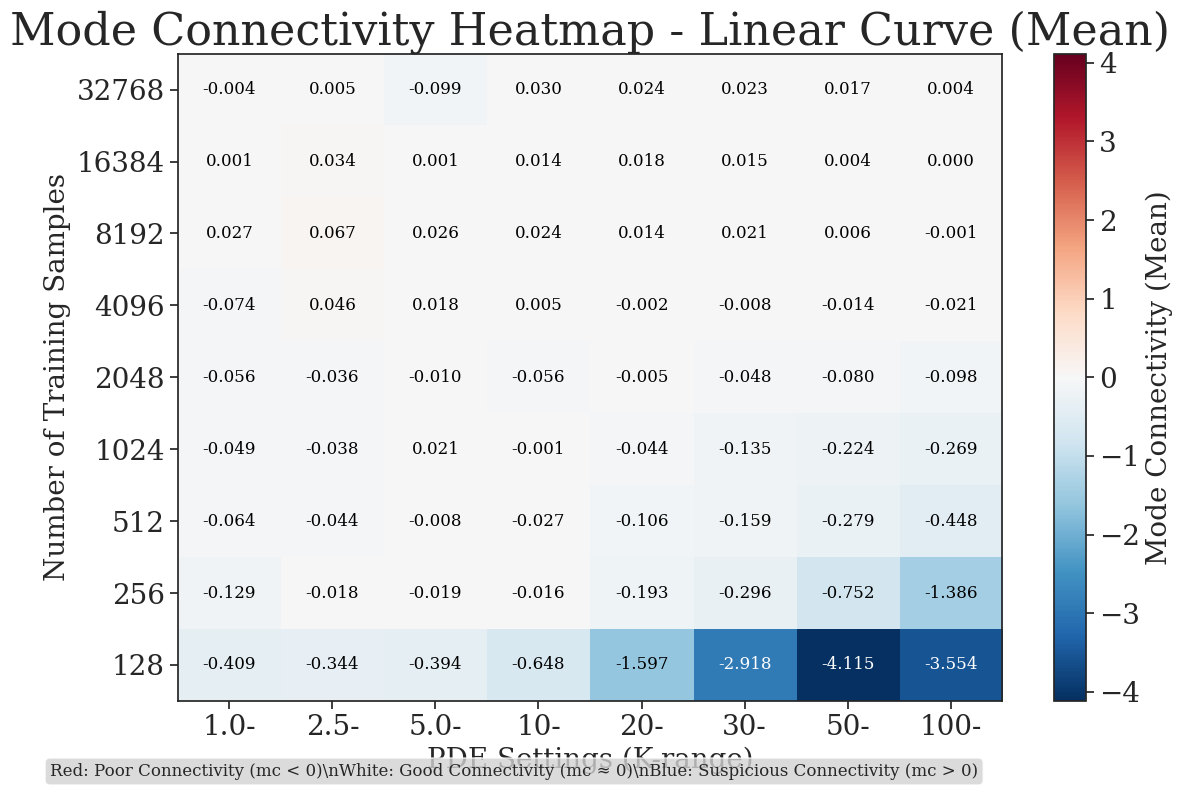

In [8]:
# Load mode connectivity statistics for both curve types
print("Loading Linear Mode Connectivity statistics...")
linear_mc_stats = load_mode_connectivity_statistics(curve_type='linear', aggregation='mean')

# Print statistics for linear curve
print_mode_connectivity_statistics(linear_mc_stats, 'linear')

# Create heatmap for linear curve
os.makedirs('./plots', exist_ok=True)
linear_im, linear_matrix = create_mode_connectivity_heatmap(
    linear_mc_stats, 
    'linear', 
    aggregation='mean',
    figsize=(12, 8),
    save_path='./plots/mode_connectivity_linear_heatmap.png'
)


Loading Linear Mode Connectivity statistics...
Processing 10 seed pairs: [(2021, 2022), (2021, 2023), (2021, 2024), (2021, 2025), (2022, 2023), (2022, 2024), (2022, 2025), (2023, 2024), (2023, 2025), (2024, 2025)]

LINEAR Curve Mode Connectivity Statistics:
  Total configurations: 72
  Missing data: 0
  Available scores: 720
  Mean MC: -0.2615
  Std MC: 1.1964
  Min MC: -10.2625
  Max MC: 3.8612
  Median MC: -0.0192
  Poor connectivity (mc < -0.001): 419 (58.2%)
  Good connectivity (-0.001 ≤ mc ≤ 0.001): 8 (1.1%)
  Suspicious connectivity (mc > 0.001): 293 (40.7%)
Heatmap saved to: ./plots/mode_connectivity_linear_heatmap.png


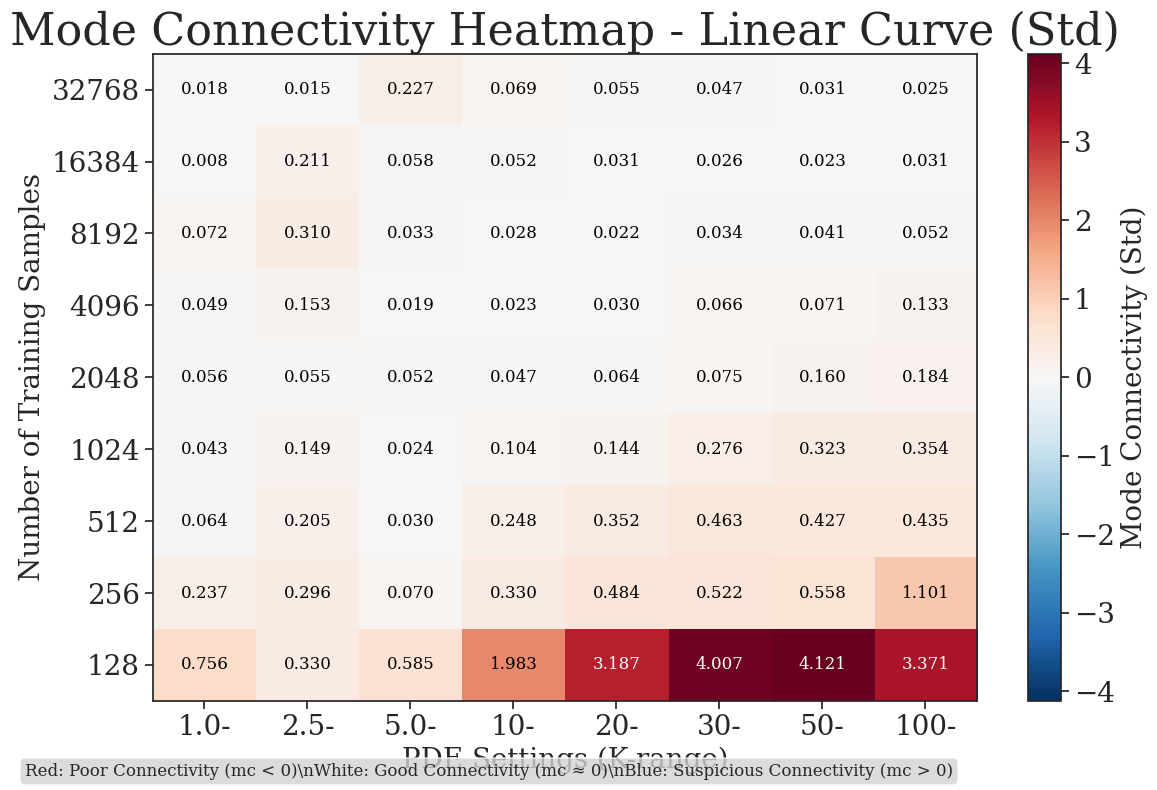

In [9]:
# Load mode connectivity statistics for both curve types
print("Loading Linear Mode Connectivity statistics...")
linear_mc_stats = load_mode_connectivity_statistics(curve_type='linear', aggregation='std')

# Print statistics for linear curve
print_mode_connectivity_statistics(linear_mc_stats, 'linear')

# Create heatmap for linear curve
os.makedirs('./plots', exist_ok=True)
linear_im, linear_matrix = create_mode_connectivity_heatmap(
    linear_mc_stats, 
    'linear', 
    aggregation='std',
    figsize=(12, 8),
    save_path='./plots/mode_connectivity_linear_heatmap.png'
)



BEZIER Curve Mode Connectivity Statistics:
  Total configurations: 72
  Missing data: 0
  Available scores: 720
  Mean MC: -0.2615
  Std MC: 1.1964
  Min MC: -10.2625
  Max MC: 3.8612
  Median MC: -0.0192
  Poor connectivity (mc < -0.001): 419 (58.2%)
  Good connectivity (-0.001 ≤ mc ≤ 0.001): 8 (1.1%)
  Suspicious connectivity (mc > 0.001): 293 (40.7%)


Heatmap saved to: ./plots/mode_connectivity_bezier_heatmap.png


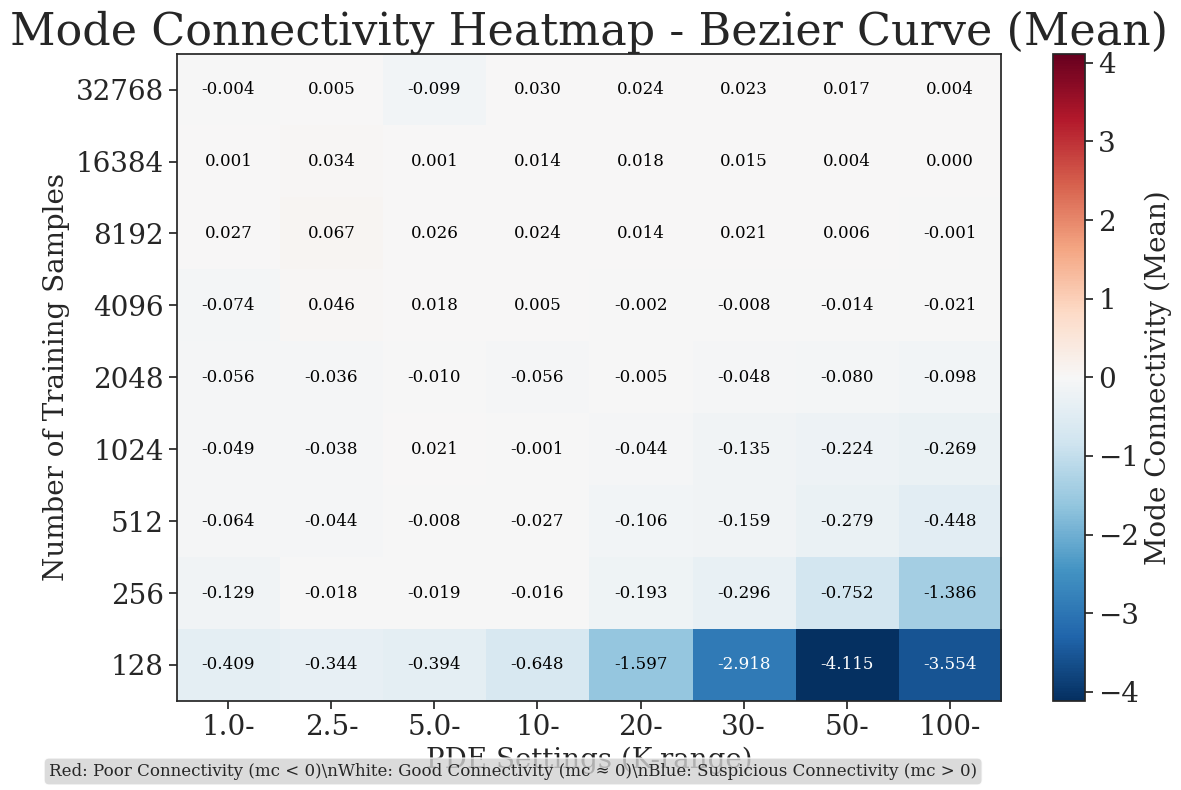

In [10]:
# Print statistics for Bézier curve
print_mode_connectivity_statistics(bezier_mc_stats, 'bezier')

# Create heatmap for Bézier curve
bezier_im, bezier_matrix = create_mode_connectivity_heatmap(
    bezier_mc_stats, 
    'bezier', 
    aggregation='mean',
    figsize=(12, 8),
    save_path='./plots/mode_connectivity_bezier_heatmap.png'
)


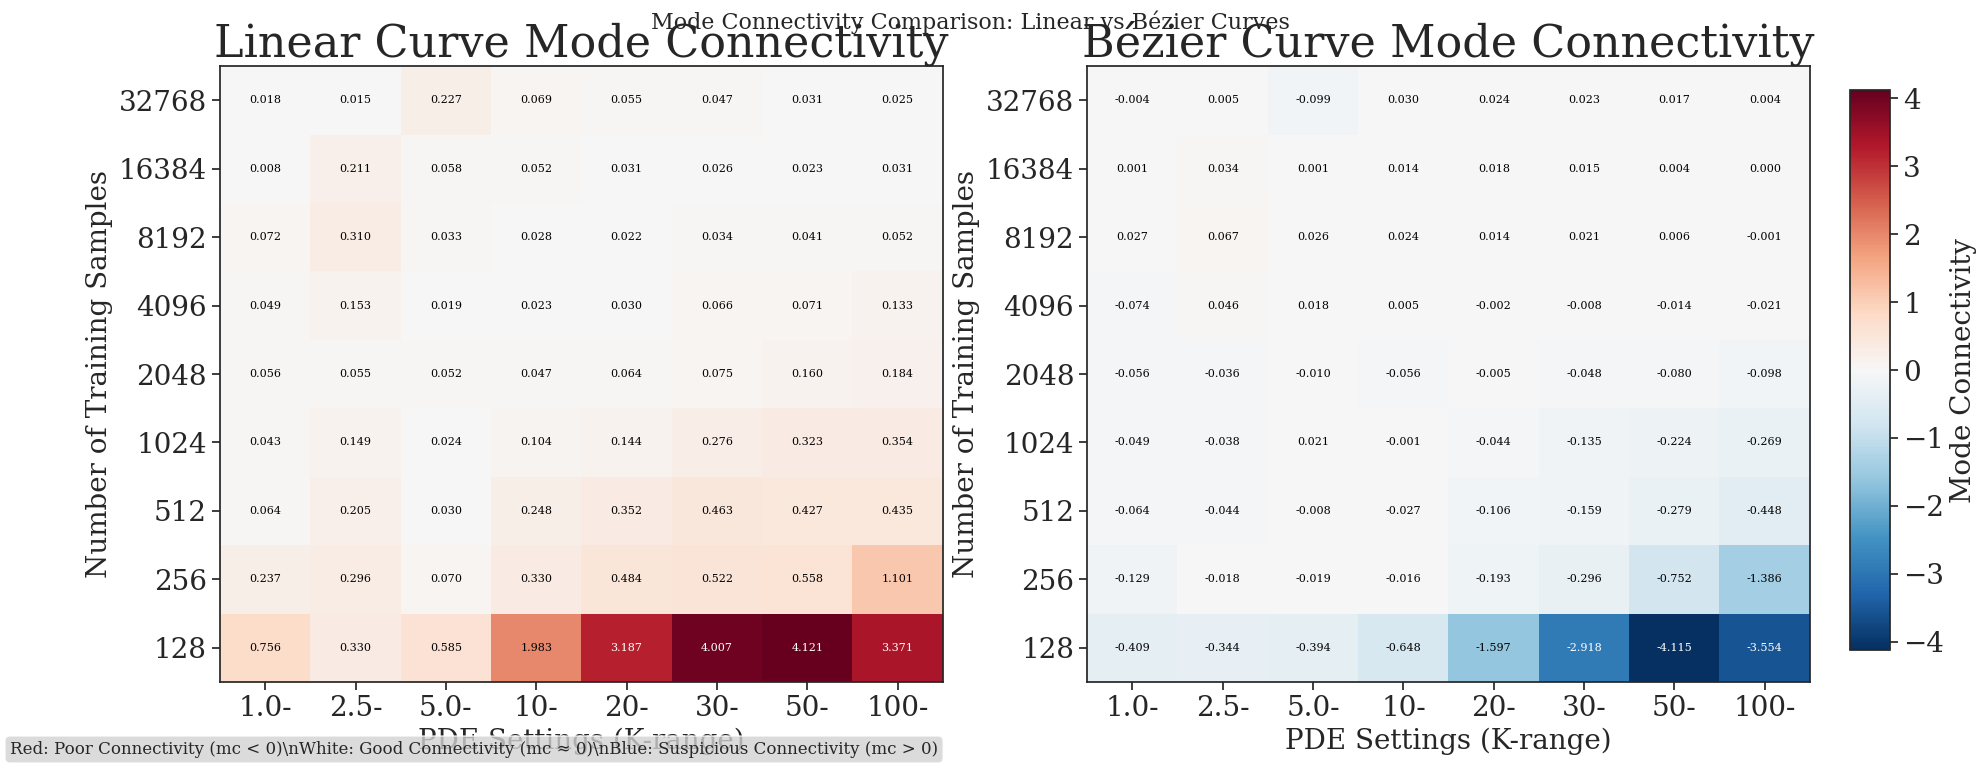

In [11]:
# Compare Linear vs Bézier curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Determine common color scale
vmax_combined = max(
    max(abs(np.nanmin(linear_matrix)), abs(np.nanmax(linear_matrix))),
    max(abs(np.nanmin(bezier_matrix)), abs(np.nanmax(bezier_matrix)))
)

# Linear curve heatmap
im1 = ax1.imshow(linear_matrix, aspect='auto', cmap='RdBu_r', origin='lower', 
                 vmin=-vmax_combined, vmax=vmax_combined)
ax1.set_xticks(np.arange(len(k_range_list)))
ax1.set_xticklabels(k_range_list, fontsize=medfont)
ax1.set_yticks(np.arange(len(sub_sampling_range)))
ax1.set_yticklabels(data_number_range, fontsize=medfont)
ax1.set_xlabel("PDE Settings (K-range)", fontsize=medfont)
ax1.set_ylabel("Number of Training Samples", fontsize=medfont)
ax1.set_title("Linear Curve Mode Connectivity", fontsize=largefont)

# Add text annotations for linear
for i in range(linear_matrix.shape[0]):
    for j in range(linear_matrix.shape[1]):
        if not np.isnan(linear_matrix[i, j]):
            text_color = 'white' if abs(linear_matrix[i, j]) > vmax_combined * 0.5 else 'black'
            ax1.text(j, i, f'{linear_matrix[i, j]:.3f}', 
                    ha='center', va='center', color=text_color, fontsize=8)
        else:
            ax1.text(j, i, 'N/A', ha='center', va='center', color='gray', fontsize=8)

# Bézier curve heatmap
im2 = ax2.imshow(bezier_matrix, aspect='auto', cmap='RdBu_r', origin='lower', 
                 vmin=-vmax_combined, vmax=vmax_combined)
ax2.set_xticks(np.arange(len(k_range_list)))
ax2.set_xticklabels(k_range_list, fontsize=medfont)
ax2.set_yticks(np.arange(len(sub_sampling_range)))
ax2.set_yticklabels(data_number_range, fontsize=medfont)
ax2.set_xlabel("PDE Settings (K-range)", fontsize=medfont)
ax2.set_ylabel("Number of Training Samples", fontsize=medfont)
ax2.set_title("Bézier Curve Mode Connectivity", fontsize=largefont)

# Add text annotations for Bézier
for i in range(bezier_matrix.shape[0]):
    for j in range(bezier_matrix.shape[1]):
        if not np.isnan(bezier_matrix[i, j]):
            text_color = 'white' if abs(bezier_matrix[i, j]) > vmax_combined * 0.5 else 'black'
            ax2.text(j, i, f'{bezier_matrix[i, j]:.3f}', 
                    ha='center', va='center', color=text_color, fontsize=8)
        else:
            ax2.text(j, i, 'N/A', ha='center', va='center', color='gray', fontsize=8)

# Add shared colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label("Mode Connectivity", fontsize=medfont)

# Add interpretation legend
legend_text = ("Red: Poor Connectivity (mc < 0)\\n"
              "White: Good Connectivity (mc ≈ 0)\\n" 
              "Blue: Suspicious Connectivity (mc > 0)")
plt.figtext(0.02, 0.02, legend_text, #fontsize=24, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))

plt.suptitle("Mode Connectivity Comparison: Linear vs Bézier Curves", fontsize=16, y=0.95)
plt.savefig('./plots/mode_connectivity_comparison_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


Creating loss barrier analysis...


Loss barrier heatmap saved to: ./plots/loss_barrier_linear_heatmap.png


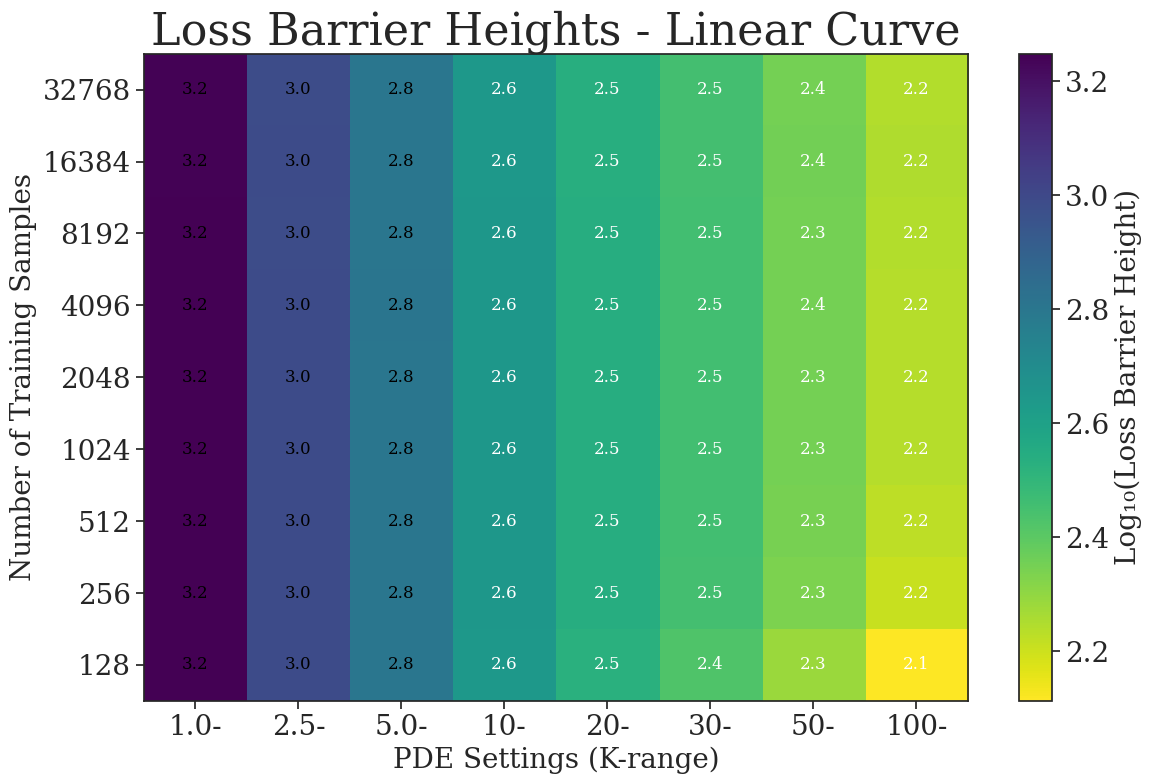

Loss barrier heatmap saved to: ./plots/loss_barrier_bezier_heatmap.png


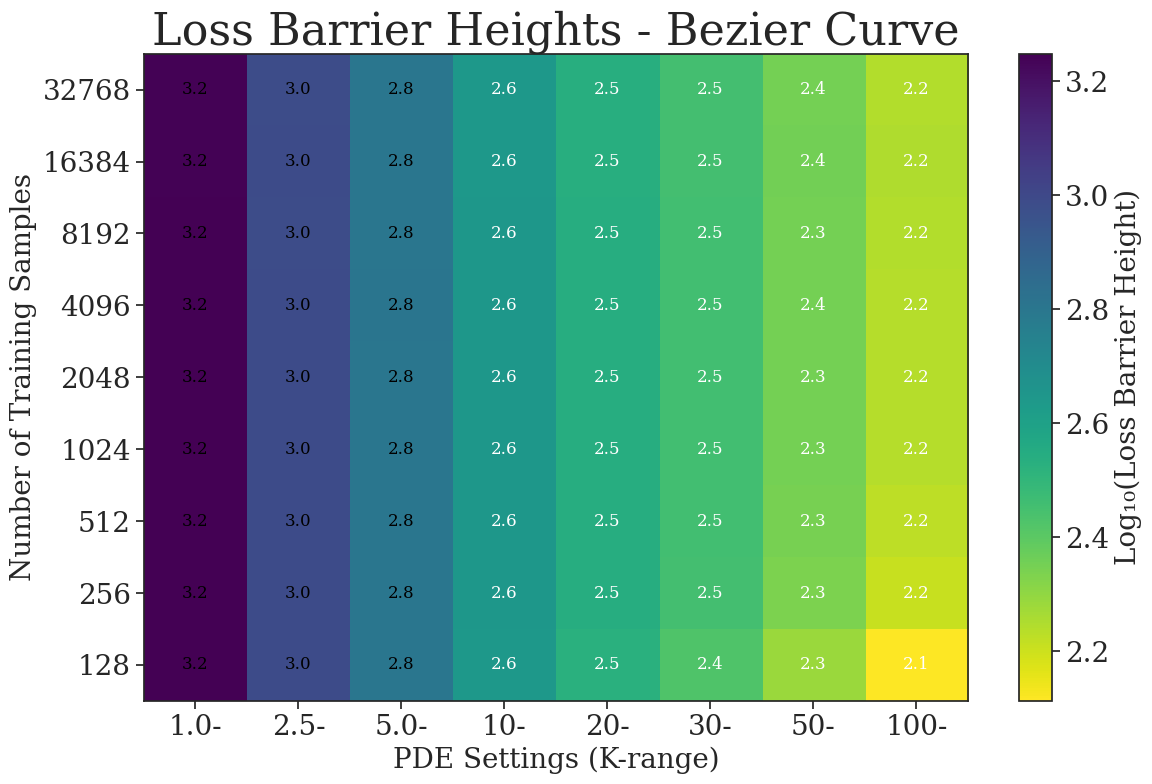

In [12]:
# Analyze loss barriers (complementary to mode connectivity)
def create_loss_barrier_heatmap(mc_stats, curve_type, figsize=(10, 8), save_path=None):
    """Create heatmap of loss barrier heights."""
    barrier_matrix = np.full((len(sub_sampling_range), len(k_ranges)), np.nan)
    
    # Fill the matrix
    for i, subsample in enumerate(sub_sampling_range):
        for j, k_range in enumerate(k_ranges):
            pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
            bsz = get_batch_size_for_subsample(subsample)
            lr = lr_range[0]
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
            
            if (pde_setting in mc_stats and 
                hyper_setting in mc_stats[pde_setting]):
                avg_barrier = mc_stats[pde_setting][hyper_setting].get('avg_loss_barrier', np.nan)
                if not np.isnan(avg_barrier) and avg_barrier > 0:
                    # Use log scale for better visualization
                    barrier_matrix[i, j] = np.log10(avg_barrier)
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Use viridis_r so that higher barriers (worse) are darker
    im = plt.imshow(barrier_matrix, aspect='auto', cmap='viridis_r', origin='lower')
    
    # Add colorbar
    cbar = plt.colorbar(im)
    cbar.set_label("Log₁₀(Loss Barrier Height)", fontsize=medfont)
    
    # Set ticks and labels
    plt.xticks(ticks=np.arange(len(k_range_list)), labels=k_range_list, fontsize=medfont)
    plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
    
    # Set labels and title
    plt.xlabel("PDE Settings (K-range)", fontsize=medfont)
    plt.ylabel("Number of Training Samples", fontsize=medfont)
    plt.title(f"Loss Barrier Heights - {curve_type.capitalize()} Curve", fontsize=largefont)
    
    # Add text annotations
    for i in range(barrier_matrix.shape[0]):
        for j in range(barrier_matrix.shape[1]):
            if not np.isnan(barrier_matrix[i, j]):
                text_color = 'white' if barrier_matrix[i, j] < np.nanmean(barrier_matrix) else 'black'
                plt.text(j, i, f'{barrier_matrix[i, j]:.1f}', 
                        ha='center', va='center', color=text_color, ) #fontsize=9
            else:
                plt.text(j, i, 'N/A', ha='center', va='center', color='gray', ) #fontsize=9
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Loss barrier heatmap saved to: {save_path}")
    
    plt.show()
    
    return im, barrier_matrix

# Create loss barrier heatmaps
print("Creating loss barrier analysis...")
linear_barrier_im, linear_barrier_matrix = create_loss_barrier_heatmap(
    linear_mc_stats, 'linear', figsize=(12, 8),
    save_path='./plots/loss_barrier_linear_heatmap.png'
)

bezier_barrier_im, bezier_barrier_matrix = create_loss_barrier_heatmap(
    bezier_mc_stats, 'bezier', figsize=(12, 8),
    save_path='./plots/loss_barrier_bezier_heatmap.png'
)


In [13]:
def analyze_specific_mc_configuration(k_range, subsample, curve_type='linear'):
    """Analyze mode connectivity results for a specific configuration across all seed pairs."""
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    bsz = get_batch_size_for_subsample(subsample)
    lr = lr_range[0]
    hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
    
    print(f"\nAnalyzing Mode Connectivity Configuration:")
    print(f"  PDE Setting: {pde_setting}")
    print(f"  Hyperparameters: {hyper_setting}")
    print(f"  Curve Type: {curve_type}")
    
    seed_pairs = list(combinations(seed_range, 2))
    results = []
    
    for seed_a, seed_b in seed_pairs:
        file_path = construct_mc_file_path(
            base_mc_dir, k_range, subsample, curve_type, seed_a, seed_b
        )
        
        if os.path.exists(file_path):
            result = parse_mode_connectivity_file(file_path)
            if result and 'mode_connectivity' in result:
                results.append({
                    'seed_pair': f'{seed_a}_vs_{seed_b}',
                    'mode_connectivity': result['mode_connectivity'],
                    'loss_barrier_height': result.get('loss_barrier_height', 'N/A'),
                    'parameter_distance': result.get('parameter_distance', 'N/A'),
                    'optimal_t': result.get('optimal_t', 'N/A')
                })
        else:
            # Try reverse order
            file_path_alt = construct_mc_file_path(
                base_mc_dir, k_range, subsample, curve_type, seed_b, seed_a
            )
            if os.path.exists(file_path_alt):
                result = parse_mode_connectivity_file(file_path_alt)
                if result and 'mode_connectivity' in result:
                    results.append({
                        'seed_pair': f'{seed_b}_vs_{seed_a}',
                        'mode_connectivity': result['mode_connectivity'],
                        'loss_barrier_height': result.get('loss_barrier_height', 'N/A'),
                        'parameter_distance': result.get('parameter_distance', 'N/A'),
                        'optimal_t': result.get('optimal_t', 'N/A')
                    })
    
    if results:
        df = pd.DataFrame(results)
        print(f"\nResults across {len(results)} seed pairs:")
        print(df.to_string(index=False))
        
        mc_scores = [r['mode_connectivity'] for r in results]
        print(f"\nSummary Statistics:")
        print(f"  Mean Mode Connectivity: {np.mean(mc_scores):.4f}")
        print(f"  Std Mode Connectivity: {np.std(mc_scores):.4f}")
        print(f"  Min Mode Connectivity: {np.min(mc_scores):.4f}")
        print(f"  Max Mode Connectivity: {np.max(mc_scores):.4f}")
        
        # Interpretation
        poor_count = sum(1 for score in mc_scores if score < -0.001)
        good_count = sum(1 for score in mc_scores if -0.001 <= score <= 0.001)
        suspicious_count = sum(1 for score in mc_scores if score > 0.001)
        
        print(f"\nConnectivity Assessment:")
        print(f"  Poor connectivity: {poor_count}/{len(mc_scores)} pairs")
        print(f"  Good connectivity: {good_count}/{len(mc_scores)} pairs")
        print(f"  Suspicious connectivity: {suspicious_count}/{len(mc_scores)} pairs")
        
        return df
    else:
        print("No results found for this configuration.")
        return None

# Example usage - analyze a specific configuration
print("Example Analysis for k=[2.5, 5.0], subsample=2, linear curve:")
example_df = analyze_specific_mc_configuration([2.5, 5.0], 2, 'linear')

print("\nAnalysis completed! Check the plots directory for saved heatmaps.")
print("\nGenerated visualizations:")
print("- Mode connectivity heatmaps (linear and Bézier)")
print("- Loss barrier analysis")
print("- Comparative analysis plots")
print("- Individual configuration analysis")


Example Analysis for k=[2.5, 5.0], subsample=2, linear curve:

Analyzing Mode Connectivity Configuration:
  PDE Setting: poisson_scale_k2.5_5.0_val1024_1M
  Hyperparameters: bsz128_lr0.001_subsample2
  Curve Type: linear

Results across 10 seed pairs:
   seed_pair  mode_connectivity  loss_barrier_height  parameter_distance  optimal_t
2022_vs_2021          -0.370427           987.715888          325.324310        0.0
2023_vs_2021          -0.233706          1003.675866          312.132782        0.0
2024_vs_2021          -0.075131          1021.152465          279.058868        0.0
2025_vs_2021          -0.061597          1005.670585          277.089264        0.0
2023_vs_2022           0.136721           901.591518          364.807312        0.0
2024_vs_2022           0.295296          1020.879053          337.915497        0.0
2025_vs_2022           0.308831           944.494959          336.525970        0.0
2024_vs_2023           0.158575           985.687443          324.925568    